In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

import pyarrow as pa
import pyarrow.parquet as pq
from tqdm import tqdm

## Get Building Info

In [ ]:
all_info = pd.read_csv(r'../src/data/HEMS_RBSA/HEMS_RBSA_BASE.csv')
key_columns = ['Conditioned_Area', 'Qty_Occupants', 'Primary_Heating_System_Type', 'Total_Wall_U-Value','Window_U-Value','Window_to_Wall_Ratio']
invalid = {'Not Available', 'Unknown', 'unknown', 'not available', 'N/A', 'n/a', ''}

def is_valid(val):
    if pd.isna(val):
        return False
    return str(val).strip() not in invalid

mask = all_info[key_columns].apply(lambda col: col.map(is_valid)).all(axis=1)
all_info_clean = all_info[mask].copy()

print(f"Kept {len(all_info_clean)} / {len(all_info)} rows")
ee_id_rbsa_clean = all_info_clean['ee_site_id'].drop_duplicates().reset_index(drop=True)
print(f"{len(ee_id_rbsa_clean)} valid sites")


FileNotFoundError: [Errno 2] No such file or directory: 'HEMS_RBSA\\HEMS_RBSA_BASE.csv'

## Select Information

In [6]:
file_path = r'../POWER15_RAW_2023 v9.2.csv'
inspect = pd.read_csv(file_path, nrows=5)
inspect

,ee_site_id,regname,min_t,max_t,n,power,apparent_power,pf,Circuit Label,End Use,MIN_T_l,MAX_T_l,state,hz,cz
0,491,CIRCUIT_3,2023-01-01 08:00:00.000,2023-01-01 08:14:00.000,15,0.000,0.016,0.000,Clothes Dryer_1,Clothes Dryer,2023-01-01 00:00:00.000,2023-01-01 00:14:00.000,OR,2,1
1,491,CIRCUIT_7,2023-01-01 08:00:00.000,2023-01-01 08:14:00.000,15,0.270,0.411,0.657,Clothes Washer_1,Clothes Washer,2023-01-01 00:00:00.000,2023-01-01 00:14:00.000,OR,2,1
2,491,CIRCUIT_17,2023-01-01 08:00:00.000,2023-01-01 08:14:00.000,15,0.000,0.008,0.000,Dishwasher_1,Dishwasher,2023-01-01 00:00:00.000,2023-01-01 00:14:00.000,OR,2,1
3,491,CIRCUIT_10,2023-01-01 08:00:00.000,2023-01-01 08:14:00.000,15,0.398,0.515,0.773,Ductless Heatpump_1,Ductless Heatpump,2023-01-01 00:00:00.000,2023-01-01 00:14:00.000,OR,2,1
4,491,CIRCUIT_26,2023-01-01 08:00:00.000,2023-01-01 08:14:00.000,15,0.714,0.777,0.918,Ductless Heatpump_2,Ductless Heatpump,2023-01-01 00:00:00.000,2023-01-01 00:14:00.000,OR,2,1


In [ ]:


valid_ids = set(ee_id_rbsa_clean)
os.makedirs('sites', exist_ok=True)

writers = {}
schema_map = {}

# Get total file size for tqdm
file_path = r'POWER15_RAW_2024 Q1-Q2 v9.2.csv'
total_bytes = os.path.getsize(file_path)

try:
    with tqdm(total=total_bytes, unit='B', unit_scale=True, desc='Reading CSV') as pbar:
        for chunk in pd.read_csv(file_path, chunksize=100_000):
            filtered = chunk[chunk['ee_site_id'].isin(valid_ids)]
            for site_id, group in filtered.groupby('ee_site_id'):
                safe_name = str(site_id).replace('/', '_').replace('\\', '_')
                table = pa.Table.from_pandas(group, preserve_index=False)
                if site_id not in writers:
                    schema_map[site_id] = table.schema
                    writers[site_id] = pq.ParquetWriter(f'sites/{safe_name}.parquet', table.schema)
                else:
                    table = table.cast(schema_map[site_id])
                writers[site_id].write_table(table)

            pbar.update(chunk.memory_usage(deep=True).sum())
            pbar.set_postfix(sites=len(writers), matched=len(filtered))

finally:
    for w in writers.values():
        w.close()

print(f"Done — saved {len(writers)} sites to sites/")




Reading CSV: 25.2GB [05:01, 83.7MB/s, matched=0, sites=251]                                


Done — saved 251 sites to sites/


In [15]:


valid_ids = set(ee_id_rbsa_clean)
os.makedirs('sites', exist_ok=True)

writers = {}
schema_map = {}

file_path = r'POWER15_RAW_2024 Q3Q4 v9.2.csv'  # update filename as needed
total_bytes = os.path.getsize(file_path)

try:
    with tqdm(total=total_bytes, unit='B', unit_scale=True, desc='Reading Q3Q4') as pbar:
        for chunk in pd.read_csv(file_path, chunksize=100_000):
            filtered = chunk[chunk['ee_site_id'].isin(valid_ids)]
            for site_id, group in filtered.groupby('ee_site_id'):
                safe_name = str(site_id).replace('/', '_').replace('\\', '_')
                table = pa.Table.from_pandas(group, preserve_index=False)
                if site_id not in writers:
                    schema_map[site_id] = table.schema
                    writers[site_id] = pq.ParquetWriter(f'sites/{safe_name}_q3q4.parquet', table.schema)
                else:
                    table = table.cast(schema_map[site_id])
                writers[site_id].write_table(table)
            pbar.update(chunk.memory_usage(deep=True).sum())
            pbar.set_postfix(sites=len(writers), matched=len(filtered))
finally:
    for w in writers.values():
        w.close()

# Merge Q1Q2 + Q3Q4 per site
print("Merging...")
for site_id in tqdm(writers.keys(), desc='Merging sites'):
    safe_name = str(site_id).replace('/', '_').replace('\\', '_')
    q1q2_path = f'sites/{safe_name}.parquet'
    q3q4_path = f'sites/{safe_name}_q3q4.parquet'
    
    tables = []
    if os.path.exists(q1q2_path):
        tables.append(pq.read_table(q1q2_path))
    tables.append(pq.read_table(q3q4_path))
    
    pq.write_table(pa.concat_tables(tables), q1q2_path)
    os.remove(q3q4_path)  # clean up temp file

print(f"Done — merged {len(writers)} sites")


Reading Q3Q4: 23.0GB [04:18, 88.9MB/s, matched=0, sites=228]                                


Merging...


Merging sites: 100%|██████████| 228/228 [02:48<00:00,  1.35it/s]

Done — merged 228 sites


## Analyze Buildings

## Building Summary — BEM info, weather station, circuit power

## Site Coverage Map

In [ ]:
import io, zipfile, urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from shapely.geometry import box

# ── Load site metadata ────────────────────────────────────────────────────────
sites_meta = pd.read_csv('../src/data/metadata/SITES v9.2.csv', dtype={'station_id': str})
valid_sites = sites_meta[sites_meta['ee_site_id'].isin(ee_id_rbsa_clean)].copy()
unique_stations = valid_sites.drop_duplicates('station_id')[['station_id', 'state', 'cz']].copy()

# ── Fetch ISD history for lat/lon ─────────────────────────────────────────────
print("Downloading ISD station history...")
resp = urllib.request.urlopen("https://www.ncei.noaa.gov/pub/data/noaa/isd-history.csv", timeout=60)
isd = pd.read_csv(io.BytesIO(resp.read()), dtype=str)
isd.columns = [c.strip().upper().replace(" ", "_") for c in isd.columns]
isd['station_id'] = isd['USAF'] + '-' + isd['WBAN']
isd['LAT'] = pd.to_numeric(isd['LAT'], errors='coerce')
isd['LON'] = pd.to_numeric(isd['LON'], errors='coerce')
isd_coords = isd[['station_id', 'LAT', 'LON', 'STATION_NAME']].dropna().drop_duplicates('station_id')

stations_geo = unique_stations.merge(isd_coords, on='station_id', how='left')
missing = stations_geo['LAT'].isna().sum()
if missing:
    print(f"WARNING: {missing} station(s) had no coordinates in ISD history")
stations_geo = stations_geo.dropna(subset=['LAT', 'LON'])

site_counts = valid_sites.groupby('station_id')['ee_site_id'].nunique().rename('n_sites')
stations_geo = stations_geo.merge(site_counts, on='station_id', how='left')
print(f"Plotting {len(stations_geo)} stations covering {int(site_counts.sum())} sites")

# ── Download US state boundaries (Census 20m, ~1 MB) ─────────────────────────
print("Downloading US state boundaries...")
resp2 = urllib.request.urlopen(
    "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip", timeout=60
)
with zipfile.ZipFile(io.BytesIO(resp2.read())) as zf:
    zf.extractall('/tmp/us_states')
states = gpd.read_file('/tmp/us_states/cb_2022_us_state_20m.shp')
states = states[~states['STUSPS'].isin(['AK', 'HI', 'PR', 'VI', 'GU', 'MP', 'AS'])]

# ── Auto-zoom to data extent with padding ─────────────────────────────────────
pad = 2.0
lon_min, lon_max = stations_geo['LON'].min() - pad, stations_geo['LON'].max() + pad
lat_min, lat_max = stations_geo['LAT'].min() - pad, stations_geo['LAT'].max() + pad
view_poly = box(lon_min, lat_min, lon_max, lat_max)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
states.plot(ax=ax, color='#f5f5f0', edgecolor='#aaaaaa', linewidth=0.6)

# Label only states that have data dots; place label at centroid of the
# clipped (visible) portion of the state so it always falls inside the view
data_states = set(stations_geo['state'].dropna().unique())
for _, row in states[states['STUSPS'].isin(data_states)].iterrows():
    clipped = row.geometry.intersection(view_poly)
    if clipped.is_empty:
        continue
    cx, cy = clipped.centroid.x, clipped.centroid.y
    ax.text(cx, cy, row['STUSPS'], ha='center', va='center',
            fontsize=8, color='#333333', fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
            zorder=4)

# Bubble scatter — size ∝ n_sites
n = stations_geo['n_sites'].values
sizes = (n / n.max()) * 400 + 20

ax.scatter(
    stations_geo['LON'], stations_geo['LAT'],
    s=sizes, alpha=0.75, zorder=5,
    c='steelblue', edgecolors='white', linewidths=0.5,
)

# Sized legend
for val in sorted({1, int(n.max() // 2), int(n.max())}):
    sz = (val / n.max()) * 400 + 20
    ax.scatter([], [], s=sz, c='steelblue', alpha=0.75,
               edgecolors='white', linewidths=0.5,
               label=f'{val} building{"s" if val != 1 else ""}')
ax.legend(title='Buildings per\nweather station', loc='lower right', framealpha=0.9, fontsize=8)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_title(
    f'RBSA Validation Sites — {int(site_counts.sum())} buildings across {len(stations_geo)} weather stations',
    fontsize=12, pad=10,
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('site_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → site_coverage_map.png")

In [ ]:
import json

# ── Set the target site ───────────────────────────────────────────────────────
TARGET_ID = 295578   # change to any ee_site_id in ee_id_rbsa_clean

DATA_DIR = r'../src/data'

# ── BEM info ─────────────────────────────────────────────────────────────────
with open(f'{DATA_DIR}/BEM/rbsa_sites.json') as f:
    bem_all = json.load(f)

bem = next((s for s in bem_all if str(s['info']['ee_site_id']) == str(TARGET_ID)), None)

if bem is None:
    print(f"No BEM entry found for ee_site_id={TARGET_ID}")
else:
    for section, data in bem.items():
        print(f"\n{'─'*40}")
        print(f"  {section.upper()}")
        print(f"{'─'*40}")
        if isinstance(data, dict):
            for k, v in data.items():
                print(f"  {k:<45} {v}")
        elif isinstance(data, list):
            for item in data:
                if isinstance(item, dict):
                    print("  " + ", ".join(f"{k}={v}" for k, v in item.items()))
                else:
                    print(f"  {item}")

# ── Weather station ───────────────────────────────────────────────────────────
sites_meta = pd.read_csv(f'{DATA_DIR}/metadata/SITES v9.2.csv', dtype={'station_id': str})
match = sites_meta[sites_meta['ee_site_id'] == TARGET_ID]
if match.empty:
    print(f"\nNo station mapping found for ee_site_id={TARGET_ID}")
else:
    station_id = match.iloc[0]['station_id']
    print(f"\n{'─'*40}")
    print(f"  WEATHER STATION")
    print(f"{'─'*40}")
    print(f"  station_id: {station_id}")

In [ ]:
# ── Circuit power usage ───────────────────────────────────────────────────────
safe_name = str(TARGET_ID).replace('/', '_').replace('\\', '_')

# Use pq.read_table to avoid pyarrow extension-type double-registration conflict
df = pq.read_table(f'{DATA_DIR}/sites/{safe_name}.parquet').to_pandas()

df['min_t'] = pd.to_datetime(df['min_t'])

# Pivot: rows = timestamp, columns = Circuit Label, values = power (kW)
power_pivot = (
    df.pivot_table(index='min_t', columns='Circuit Label', values='power', aggfunc='mean')
    .sort_index()
)

# Household total: sum of all non-Mains circuits (Mains is the measured whole-house draw)
mains_cols = [c for c in power_pivot.columns if 'Mains' in c]
circuit_cols = [c for c in power_pivot.columns if 'Mains' not in c]
power_pivot['Household_Total'] = power_pivot[circuit_cols].sum(axis=1)

print(f"Site: {TARGET_ID}  |  {power_pivot.index[0]}  →  {power_pivot.index[-1]}")
print(f"Circuits: {len(circuit_cols)}  (+{len(mains_cols)} Mains)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_circuits, ax_total) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: one line per circuit (excluding Mains)
cmap = plt.get_cmap('tab20')
for i, col in enumerate(circuit_cols):
    ax_circuits.plot(
        power_pivot.index, power_pivot[col],
        linewidth=0.6, alpha=0.8,
        color=cmap(i % 20),
        label=col,
    )
ax_circuits.set_ylabel('Power (kW)')
ax_circuits.set_title(f'Circuit Power Usage — Site {TARGET_ID}')
ax_circuits.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.5)

# Bottom: household total vs Mains (measured whole-house)
ax_total.plot(power_pivot.index, power_pivot['Household_Total'],
              linewidth=0.8, color='steelblue', label='Household Total (sum of circuits)')
for col in mains_cols:
    ax_total.plot(power_pivot.index, power_pivot[col],
                  linewidth=0.8, color='tomato', linestyle='--', label=f'{col} (measured)')
ax_total.set_ylabel('Power (kW)')
ax_total.set_title('Household Total vs Mains')
ax_total.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
example_id = ee_id_rbsa_clean.iloc[1]
safe_name = str(example_id).replace('/', '_').replace('\\', '_')
df_example = pd.read_parquet(f'sites/{safe_name}.parquet')

print(f"Site: {example_id}")
print(f"Shape: {df_example.shape}")
for i, col in enumerate(df_example.columns):
    print(i, col)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_example.head(10).to_string())

# Find the circuit column (may be named differently)
print(df_example['Circuit Label'].value_counts(dropna=False))



Site: 295578
Shape: (969917, 15)
0 ee_site_id
1 regname
2 min_t
3 max_t
4 n
5 power
6 apparent_power
7 pf
8 Circuit Label
9 End Use
10 MIN_T_l
11 MAX_T_l
12 state
13 hz
14 cz
   ee_site_id     regname                    min_t                    max_t   n  power  apparent_power     pf              Circuit Label                  End Use                  MIN_T_l                  MAX_T_l state  hz  cz
0      295578   CIRCUIT_4  2024-01-01 07:00:00.000  2024-01-01 07:14:00.000  15  0.002           0.011  0.182               Central AC_1               Central AC  2024-01-01 00:00:00.000  2024-01-01 00:14:00.000    ID   1   3
1      295578   CIRCUIT_6  2024-01-01 07:00:00.000  2024-01-01 07:14:00.000  15  0.001           0.011  0.091            Clothes Dryer_1            Clothes Dryer  2024-01-01 00:00:00.000  2024-01-01 00:14:00.000    ID   1   3
2      295578  CIRCUIT_23  2024-01-01 07:00:00.000  2024-01-01 07:14:00.000  15  0.001           0.006  0.167           Clothes Washer_1           

Rows: 33464, Range: 2024-01-01 07:00:00 → 2025-06-16 23:45:00


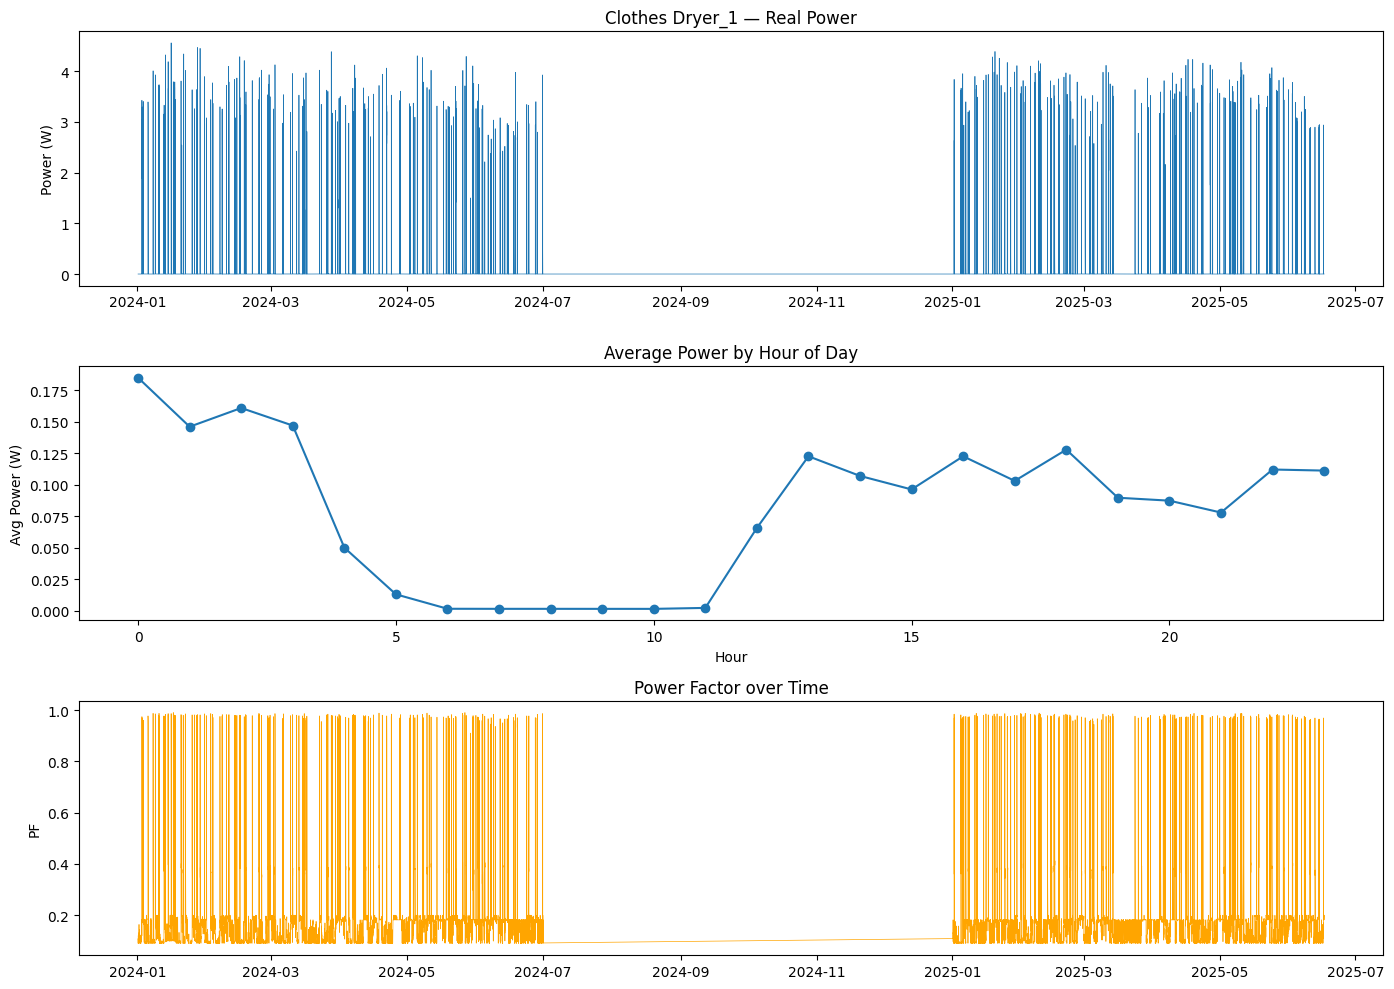

In [5]:
# Pick one circuit to examine
circuit = 'Clothes Dryer_1'
sub = df_example[df_example['Circuit Label'] == circuit].sort_values('min_t').copy()
sub['min_t'] = pd.to_datetime(sub['min_t'])


print(f"Rows: {len(sub)}, Range: {sub['min_t'].min()} → {sub['min_t'].max()}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Time series
axes[0].plot(sub['min_t'], sub['power'], linewidth=0.5)
axes[0].set_title(f'{circuit} — Real Power')
axes[0].set_ylabel('Power (W)')

# 2. Daily average profile
sub['hour'] = sub['min_t'].dt.hour
hourly = sub.groupby('hour')['power'].mean()
axes[1].plot(hourly.index, hourly.values, marker='o')
axes[1].set_title('Average Power by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Power (W)')

# 3. PF over time
axes[2].plot(sub['min_t'], sub['pf'], linewidth=0.5, color='orange')
axes[2].set_title('Power Factor over Time')
axes[2].set_ylabel('PF')

plt.tight_layout()
plt.show()
